# Clase 5.2: Ejercicio Integrador — Preprocesamiento de Datos Financieros

**Alumno:** Gallego, Ian  
**Materia:** Mineria de Datos

---

## Contexto del Problema

Trabajamos en una empresa de análisis financiero con un dataset de clientes bancarios.  
El objetivo es **preparar los datos para un modelo de predicción de solvencia financiera**, aplicando todas las técnicas de limpieza y transformación vistas en clase.

| Sección | Contenido |
|---------|----------|
| 4.1 | Dataset y exploración inicial |
| 4.2 | Limpieza de datos (nulos + outliers) |
| 4.3 | Transformación numérica (Min-Max + Z-score) |
| 4.4 | Transformación categórica (One-Hot + Label Encoding) |
| 4.5 | Interacción con LLM |
| 4.6 | Visualizaciones comparativas |
| 5 | Reflexión final y síntesis |

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Librerías importadas correctamente.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Librerías importadas correctamente.
pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


---
## Sección 4: Ejercicio Integrador

### 4.1 Dataset — Clientes Bancarios

In [32]:
# Crear DataFrame con el dataset de clientes bancarios
df = pd.DataFrame({
    "Cliente":         [1,       2,       3,       4,       5,       6,       7,       8      ],
    "Edad":            [25,      40,      35,      50,      30,      45,      38,      29     ],
    "Ingresos":        [50000,   60000,   70000,   80000,   45000,   85000,   72000,   48000  ],
    "Historial_Pagos": ["Bueno", "Regular","Malo",  "Bueno", "Regular","Malo",  "Bueno", "Regular"],
    "Categoría":       ["A",     "B",     "C",     "A",     "B",     "C",     "A",     "B"    ]
})

print("=== Dataset original ===")
display(df)
print(f"\nShape: {df.shape}  ({df.shape[0]} filas × {df.shape[1]} columnas)")
print("\n=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Estadísticas descriptivas ===")
display(df.describe(include='all'))

=== Dataset original ===


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B



Shape: (8, 5)  (8 filas × 5 columnas)

=== Tipos de datos ===
Cliente            int64
Edad               int64
Ingresos           int64
Historial_Pagos      str
Categoría            str
dtype: object

=== Estadísticas descriptivas ===


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
count,8.00000,8.000000,8.000000,8,8
unique,NaN,NaN,NaN,3,3
top,NaN,NaN,NaN,Bueno,A
freq,NaN,NaN,NaN,3,3
mean,4.50000,36.500000,63750.000000,NaN,NaN
std,2.44949,8.468429,15238.578861,NaN,NaN
min,1.00000,25.000000,45000.000000,NaN,NaN
25%,2.75000,29.750000,49500.000000,NaN,NaN
50%,4.50000,36.500000,65000.000000,NaN,NaN
75%,6.25000,41.250000,74000.000000,NaN,NaN


---
### 4.2 Limpieza de Datos

#### Paso A — Identificación y manejo de valores nulos

In [33]:
# Verificar valores nulos en el dataset
print("=== Valores nulos por columna ===")
nulos = df.isnull().sum()
print(nulos)
print(f"\nTotal de valores nulos: {nulos.sum()}")

# Simulación: introducimos un valor nulo para demostrar el manejo
df_demo = df.copy()
df_demo.loc[2, "Edad"] = np.nan
df_demo.loc[5, "Ingresos"] = np.nan

print("\n=== Dataset con nulos simulados ===")
display(df_demo)
print(f"\nNulos por columna tras simulación:\n{df_demo.isnull().sum()}")

# Imputar con la mediana (robusta ante outliers)
mediana_edad     = df_demo["Edad"].median()
mediana_ingresos = df_demo["Ingresos"].median()

df_demo["Edad"]     = df_demo["Edad"].fillna(mediana_edad)
df_demo["Ingresos"] = df_demo["Ingresos"].fillna(mediana_ingresos)

print(f"\nMediana usada para 'Edad':     {mediana_edad}")
print(f"Mediana usada para 'Ingresos': {mediana_ingresos:,.0f}")
print(f"\nNulos restantes: {df_demo.isnull().sum().sum()}")
print("\n=== Dataset tras imputación ===")
display(df_demo)

=== Valores nulos por columna ===
Cliente            0
Edad               0
Ingresos           0
Historial_Pagos    0
Categoría          0
dtype: int64

Total de valores nulos: 0

=== Dataset con nulos simulados ===


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25.0,50000.0,Bueno,A
1,2,40.0,60000.0,Regular,B
2,3,NaN,70000.0,Malo,C
3,4,50.0,80000.0,Bueno,A
4,5,30.0,45000.0,Regular,B
5,6,45.0,NaN,Malo,C
6,7,38.0,72000.0,Bueno,A
7,8,29.0,48000.0,Regular,B



Nulos por columna tras simulación:
Cliente            0
Edad               1
Ingresos           1
Historial_Pagos    0
Categoría          0
dtype: int64

Mediana usada para 'Edad':     38.0
Mediana usada para 'Ingresos': 60,000

Nulos restantes: 0

=== Dataset tras imputación ===


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25.0,50000.0,Bueno,A
1,2,40.0,60000.0,Regular,B
2,3,38.0,70000.0,Malo,C
3,4,50.0,80000.0,Bueno,A
4,5,30.0,45000.0,Regular,B
5,6,45.0,60000.0,Malo,C
6,7,38.0,72000.0,Bueno,A
7,8,29.0,48000.0,Regular,B


#### Paso B — Detección de outliers en `Ingresos` con el método IQR

In [34]:
# Trabajamos sobre el dataset original limpio (sin nulos reales)
df_trabajo = df.copy()

# Cálculo del IQR para 'Ingresos'
Q1  = df_trabajo["Ingresos"].quantile(0.25)
Q3  = df_trabajo["Ingresos"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1 = ${Q1:,.0f}  |  Q3 = ${Q3:,.0f}  |  IQR = ${IQR:,.0f}")
print(f"Límite inferior: ${limite_inferior:,.0f}")
print(f"Límite superior: ${limite_superior:,.0f}")

# Detectar outliers
outliers = df_trabajo[
    (df_trabajo["Ingresos"] < limite_inferior) |
    (df_trabajo["Ingresos"] > limite_superior)
]

print(f"\nOutliers detectados en 'Ingresos': {len(outliers)}")
if len(outliers) > 0:
    display(outliers)
else:
    print("→ No se detectaron outliers en el dataset actual (todos los ingresos caen dentro del rango IQR).")
    print(f"  Rango real de Ingresos: [${df_trabajo['Ingresos'].min():,} — ${df_trabajo['Ingresos'].max():,}]")

# Decisión: conservar todos los registros (sin outliers a eliminar)
df_cleaned = df_trabajo[
    (df_trabajo["Ingresos"] >= limite_inferior) &
    (df_trabajo["Ingresos"] <= limite_superior)
].copy().reset_index(drop=True)

print(f"\nFilas antes: {len(df_trabajo)}  |  Filas después: {len(df_cleaned)}")
print("\n=== Dataset limpio (df_cleaned) ===")
display(df_cleaned)

Q1 = $49,500  |  Q3 = $74,000  |  IQR = $24,500
Límite inferior: $12,750
Límite superior: $110,750

Outliers detectados en 'Ingresos': 0
→ No se detectaron outliers en el dataset actual (todos los ingresos caen dentro del rango IQR).
  Rango real de Ingresos: [$45,000 — $85,000]

Filas antes: 8  |  Filas después: 8

=== Dataset limpio (df_cleaned) ===


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


---
### 4.3 Transformación de Datos Numéricos

Se aplican dos técnicas de escalado:
- **Min-Max Scaling** sobre `Ingresos` → rango [0, 1]
- **Z-score Scaling (Estandarización)** sobre `Edad` → media 0, desviación estándar 1

In [35]:
# Min-Max Scaling — Ingresos
scaler_minmax = MinMaxScaler()
df_cleaned["Ingresos_Normalizado"] = scaler_minmax.fit_transform(df_cleaned[["Ingresos"]])

# Z-score Scaling — Edad
scaler_std = StandardScaler()
df_cleaned["Edad_Estandarizada"] = scaler_std.fit_transform(df_cleaned[["Edad"]])

print("=== Comparación: originales vs. transformados ===")
comparacion = df_cleaned[["Cliente", "Edad", "Edad_Estandarizada", "Ingresos", "Ingresos_Normalizado"]].copy()
display(comparacion)

print("\n=== Estadísticas después de la transformación ===")
stats = pd.DataFrame({
    "Edad (original)":         df_cleaned["Edad"].describe(),
    "Edad (Z-score)":          df_cleaned["Edad_Estandarizada"].describe(),
    "Ingresos (original)":     df_cleaned["Ingresos"].describe(),
    "Ingresos (Min-Max)":      df_cleaned["Ingresos_Normalizado"].describe()
}).round(4)
display(stats)

print("\n→ Edad_Estandarizada: media ≈ 0, std ≈ 1  (Z-score correcto)")
print("→ Ingresos_Normalizado: rango exactamente [0, 1]  (Min-Max correcto)")

=== Comparación: originales vs. transformados ===


,Cliente,Edad,Edad_Estandarizada,Ingresos,Ingresos_Normalizado
0,1,25,-1.451747,50000,0.125
1,2,40,0.441836,60000,0.375
2,3,35,-0.189358,70000,0.625
3,4,50,1.704225,80000,0.875
4,5,30,-0.820553,45000,0.000
5,6,45,1.073030,85000,1.000
6,7,38,0.189358,72000,0.675
7,8,29,-0.946792,48000,0.075



=== Estadísticas después de la transformación ===


,Edad (original),Edad (Z-score),Ingresos (original),Ingresos (Min-Max)
count,8.0000,8.0000,8.0000,8.0000
mean,36.5000,-0.0000,63750.0000,0.4688
std,8.4684,1.0690,15238.5789,0.3810
min,25.0000,-1.4517,45000.0000,0.0000
25%,29.7500,-0.8521,49500.0000,0.1125
50%,36.5000,0.0000,65000.0000,0.5000
75%,41.2500,0.5996,74000.0000,0.7250
max,50.0000,1.7042,85000.0000,1.0000



→ Edad_Estandarizada: media ≈ 0, std ≈ 1  (Z-score correcto)
→ Ingresos_Normalizado: rango exactamente [0, 1]  (Min-Max correcto)


---
### 4.4  Transformación de Datos Categóricos

- **One-Hot Encoding** en `Historial_Pagos` (nominal sin orden intrínseco necesario para el modelo)
- **Label Encoding** en `Categoría` (nominal corta, 3 categorías: A, B, C)

In [36]:
print("=== Antes del encoding ===")
print(f"Historial_Pagos — valores únicos: {df_cleaned['Historial_Pagos'].unique().tolist()}")
print(f"Categoría        — valores únicos: {df_cleaned['Categoría'].unique().tolist()}")

# One-Hot Encoding — Historial_Pagos
df_encoded = pd.get_dummies(df_cleaned, columns=["Historial_Pagos"], prefix="Historial", dtype=int)

# Label Encoding — Categoría
le = LabelEncoder()
df_encoded["Categoría_Label"] = le.fit_transform(df_encoded["Categoría"])

print("\n=== Mapeo de Label Encoding para Categoría ===")
for clase, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"  '{clase}'  →  {codigo}")

print("\n=== Dataset tras encoding categórico ===")
cols_mostrar = ["Cliente", "Categoría", "Categoría_Label",
                "Historial_Bueno", "Historial_Malo", "Historial_Regular"]
display(df_encoded[cols_mostrar])

print("\n=== Dataset final completo ===")
display(df_encoded)

=== Antes del encoding ===
Historial_Pagos — valores únicos: ['Bueno', 'Regular', 'Malo']
Categoría        — valores únicos: ['A', 'B', 'C']

=== Mapeo de Label Encoding para Categoría ===
  'A'  →  0
  'B'  →  1
  'C'  →  2

=== Dataset tras encoding categórico ===


,Cliente,Categoría,Categoría_Label,Historial_Bueno,Historial_Malo,Historial_Regular
0,1,A,0,1,0,0
1,2,B,1,0,0,1
2,3,C,2,0,1,0
3,4,A,0,1,0,0
4,5,B,1,0,0,1
5,6,C,2,0,1,0
6,7,A,0,1,0,0
7,8,B,1,0,0,1



=== Dataset final completo ===


,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoría_Label
0,1,25,50000,A,0.125,-1.451747,1,0,0,0
1,2,40,60000,B,0.375,0.441836,0,0,1,1
2,3,35,70000,C,0.625,-0.189358,0,1,0,2
3,4,50,80000,A,0.875,1.704225,1,0,0,0
4,5,30,45000,B,0.000,-0.820553,0,0,1,1
5,6,45,85000,C,1.000,1.073030,0,1,0,2
6,7,38,72000,A,0.675,0.189358,1,0,0,0
7,8,29,48000,B,0.075,-0.946792,0,0,1,1


---
### 4.5 Interacción con una Herramienta LLM

#### Consulta realizada a Claude (Anthropic)

 **Prompt enviado:**  
"¿Qué métodos avanzados de imputación de datos recomiendas para conjuntos de datos con muchas variables numéricas y categóricas? Tengo un dataset financiero con ~500 filas y 15 columnas, con hasta un 20% de valores faltantes en algunas variables numéricas y un 5% en categóricas. ¿Cuándo usar KNN Imputer vs MICE vs imputación con la mediana?"

---

#### Síntesis de la respuesta del LLM

El LLM estructuró la respuesta en tres niveles según la complejidad del problema:

**1. Imputación simple (mediana / moda):**  
Adecuada cuando: los datos son Missing Completely At Random (MCAR), el porcentaje de nulos es bajo (<5%) y la variable tiene poca correlación con las demás. Rápida y no introduce varianza adicional, pero ignora las relaciones entre variables.

**2. KNN Imputer (`sklearn.impute.KNNImputer`):**  
Recomendado cuando: hay correlaciones entre variables y el dataset no es demasiado grande (<50K filas, ya que el costo computacional es O(n²)). Imputa cada valor faltante usando el promedio de los K vecinos más cercanos en el espacio de las demás variables. Respeta la estructura local de los datos.

**3. MICE — Multiple Imputation by Chained Equations (`sklearn.impute.IterativeImputer`):**  
El más avanzado: modela cada variable con datos faltantes como función de las demás, iterando hasta convergencia. Maneja bien tanto variables numéricas como categóricas. Recomendado cuando: los datos son Missing At Random (MAR) y se requiere preservar las distribuciones marginales y las correlaciones entre variables. Genera incertidumbre cuantificable en las imputaciones.

**Guía de selección según el LLM:**

| Situación | Método recomendado |
|-----------|-------------------|
| <5% nulos, baja correlación | Mediana / Moda |
| 5–20% nulos, correlaciones moderadas | KNN Imputer |
| >20% nulos o correlaciones altas | MICE (IterativeImputer) |
| Variables con patrón temporal | Interpolación (forward fill) |

---

#### Comparación con lo aprendido en clase

| Aspecto | Clase | LLM (Claude) |
|---------|-------|--------------|
| Método base | Mediana / Moda | Coincide, identifica sus limitaciones |
| Cuándo usar moda | Variables categóricas | Coincide |
| Alternativas avanzadas | No cubiertas | KNN Imputer y MICE |
| Consideración de MAR/MCAR | Mencionada | Desarrollada con criterios de selección |
| Implementación práctica | Código básico | Ejemplos con `IterativeImputer` |

**Reflexión:** El LLM complementa lo visto en clase con un marco de decisión más sistemático. La clase enseña las técnicas fundamentales; el LLM ayuda a elegir entre ellas según las características del dataset. Sin embargo, el LLM no reemplaza el juicio del analista: la elección final depende de conocer el dominio del dato (¿por qué faltan esos valores?) más que solo la cantidad de nulos.

In [37]:
# Demostración práctica del KNN Imputer mencionado por el LLM
from sklearn.impute import KNNImputer

# Creamos un dataset con nulos para demostrar KNN Imputer
df_con_nulos = df[["Edad", "Ingresos"]].copy().astype(float)
df_con_nulos.loc[2, "Edad"]     = np.nan
df_con_nulos.loc[5, "Ingresos"] = np.nan
df_con_nulos.loc[7, "Edad"]     = np.nan

print("Dataset con nulos (para demostración de KNN Imputer):")
print(df_con_nulos.to_string())

# Aplicar KNN Imputer (K=3 vecinos)
knn_imputer = KNNImputer(n_neighbors=3)
datos_imputados = knn_imputer.fit_transform(df_con_nulos)
df_knn = pd.DataFrame(datos_imputados, columns=["Edad_KNN", "Ingresos_KNN"]).round(1)

# Comparar mediana vs KNN
df_comparacion = pd.concat([df_con_nulos, df_knn], axis=1)
df_comparacion["Edad_Mediana"]     = df_con_nulos["Edad"].fillna(df_con_nulos["Edad"].median())
df_comparacion["Ingresos_Mediana"] = df_con_nulos["Ingresos"].fillna(df_con_nulos["Ingresos"].median())

print("\n=== Comparación: Mediana vs. KNN Imputer ===")
print("(Solo se muestran las filas con imputación)")
filas_nulas = [2, 5, 7]
display(df_comparacion.iloc[filas_nulas][
    ["Edad", "Edad_Mediana", "Edad_KNN", "Ingresos", "Ingresos_Mediana", "Ingresos_KNN"]
])

print("\n→ El KNN Imputer considera la proximidad con otros clientes para imputar,")
print("  mientras que la mediana usa un valor global independiente del contexto.")

Dataset con nulos (para demostración de KNN Imputer):
   Edad  Ingresos
0  25.0   50000.0
1  40.0   60000.0
2   NaN   70000.0
3  50.0   80000.0
4  30.0   45000.0
5  45.0       NaN
6  38.0   72000.0
7   NaN   48000.0

=== Comparación: Mediana vs. KNN Imputer ===
(Solo se muestran las filas con imputación)


,Edad,Edad_Mediana,Edad_KNN,Ingresos,Ingresos_Mediana,Ingresos_KNN
2,NaN,39.0,42.7,70000.0,70000.0,70000.0
5,45.0,45.0,45.0,NaN,60000.0,70666.7
7,NaN,39.0,31.7,48000.0,48000.0,48000.0



→ El KNN Imputer considera la proximidad con otros clientes para imputar,
  mientras que la mediana usa un valor global independiente del contexto.


---
### 4.6 Visualizaciones Comparativas — Antes y Después del Preprocesamiento

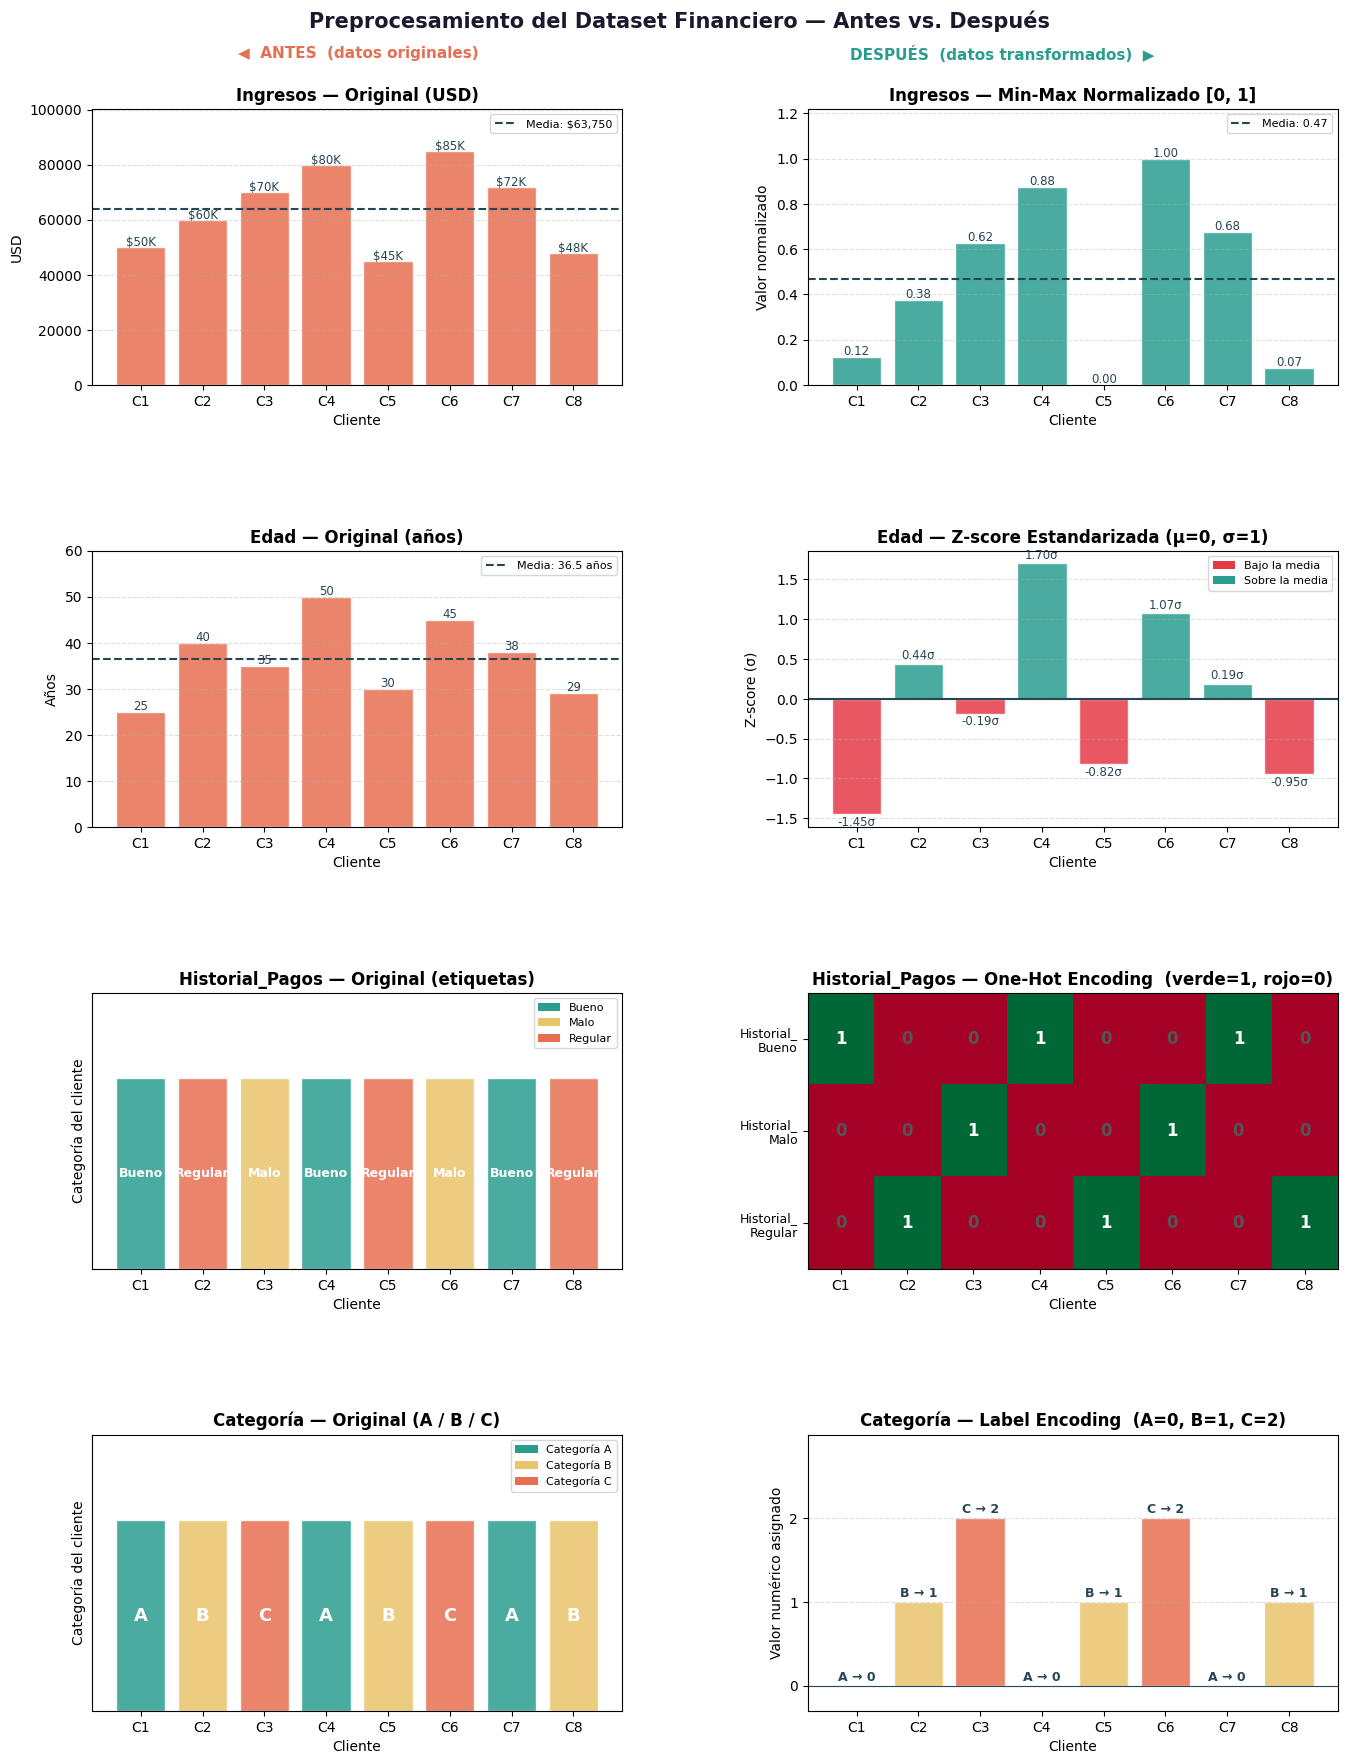

→ Gráfico guardado como 'clase52_antes_despues.png'


In [38]:
# Paleta de colores consistente
COLOR_ANTES   = "#e76f51"   # naranja: estado original
COLOR_DESPUES = "#2a9d8f"   # verde:   estado transformado
COLOR_NEG     = "#e63946"   # rojo:    valores bajo la media (Z-score)

etiquetas_c = [f"C{c}" for c in df_cleaned["Cliente"].tolist()]

# Datos categóricos necesarios
cat_orden   = ["Bueno", "Malo", "Regular"]
colores_cat = {"Bueno": COLOR_DESPUES, "Malo": "#e9c46a", "Regular": COLOR_ANTES}
hist_pagos  = df_cleaned["Historial_Pagos"].tolist()
categorias  = df_encoded["Categoría"].tolist()
cat_labels  = df_encoded["Categoría_Label"].tolist()
colores_abc = {"A": COLOR_DESPUES, "B": "#e9c46a", "C": COLOR_ANTES}

from matplotlib.patches import Patch

# ── Layout: 4 filas × 2 columnas ──────────────────────────────────────────
fig = plt.figure(figsize=(14, 18))
gs  = fig.add_gridspec(4, 2, hspace=0.6, wspace=0.35,
                        top=0.93, bottom=0.04, left=0.08, right=0.97)

# Título principal (arriba de todo, bien separado)
fig.text(0.5, 0.985,
         "Preprocesamiento del Dataset Financiero — Antes vs. Después",
         ha='center', va='top', fontsize=15, fontweight='bold', color='#1a1a2e')

# Encabezados de columna (debajo del título, sin toparse)
fig.text(0.27, 0.965, "◀  ANTES  (datos originales)",
         ha='center', va='top', fontsize=11, fontweight='bold', color=COLOR_ANTES)
fig.text(0.73, 0.965, "DESPUÉS  (datos transformados)  ▶",
         ha='center', va='top', fontsize=11, fontweight='bold', color=COLOR_DESPUES)

# ── FILA 1: Ingresos ──────────────────────────────────────────────────────
ax1a = fig.add_subplot(gs[0, 0])
ax1b = fig.add_subplot(gs[0, 1])

ax1a.bar(etiquetas_c, df_cleaned["Ingresos"], color=COLOR_ANTES, alpha=0.85, edgecolor="white")
media_ing = df_cleaned["Ingresos"].mean()
ax1a.axhline(media_ing, color="#264653", linestyle="--", linewidth=1.5,
             label=f"Media: ${media_ing:,.0f}")
for i, v in enumerate(df_cleaned["Ingresos"]):
    ax1a.text(i, v + 500, f"${v//1000}K", ha='center', fontsize=8.5, color="#264653")
ax1a.set_title("Ingresos — Original (USD)", fontweight='bold')
ax1a.set_ylabel("USD")
ax1a.set_xlabel("Cliente")
ax1a.legend(fontsize=8)
ax1a.grid(axis='y', linestyle='--', alpha=0.4)
ax1a.set_ylim(0, df_cleaned["Ingresos"].max() * 1.18)

ax1b.bar(etiquetas_c, df_cleaned["Ingresos_Normalizado"], color=COLOR_DESPUES, alpha=0.85, edgecolor="white")
media_norm = df_cleaned["Ingresos_Normalizado"].mean()
ax1b.axhline(media_norm, color="#264653", linestyle="--", linewidth=1.5,
             label=f"Media: {media_norm:.2f}")
for i, v in enumerate(df_cleaned["Ingresos_Normalizado"]):
    ax1b.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=8.5, color="#264653")
ax1b.set_title("Ingresos — Min-Max Normalizado [0, 1]", fontweight='bold')
ax1b.set_ylabel("Valor normalizado")
ax1b.set_xlabel("Cliente")
ax1b.set_ylim(0, 1.22)
ax1b.legend(fontsize=8)
ax1b.grid(axis='y', linestyle='--', alpha=0.4)

# ── FILA 2: Edad ──────────────────────────────────────────────────────────
ax2a = fig.add_subplot(gs[1, 0])
ax2b = fig.add_subplot(gs[1, 1])

ax2a.bar(etiquetas_c, df_cleaned["Edad"], color=COLOR_ANTES, alpha=0.85, edgecolor="white")
media_edad = df_cleaned["Edad"].mean()
ax2a.axhline(media_edad, color="#264653", linestyle="--", linewidth=1.5,
             label=f"Media: {media_edad:.1f} años")
for i, v in enumerate(df_cleaned["Edad"]):
    ax2a.text(i, v + 0.5, str(v), ha='center', fontsize=8.5, color="#264653")
ax2a.set_title("Edad — Original (años)", fontweight='bold')
ax2a.set_ylabel("Años")
ax2a.set_xlabel("Cliente")
ax2a.legend(fontsize=8)
ax2a.set_ylim(0, df_cleaned["Edad"].max() * 1.2)
ax2a.grid(axis='y', linestyle='--', alpha=0.4)

z_vals = df_cleaned["Edad_Estandarizada"].tolist()
colores_z = [COLOR_NEG if v < 0 else COLOR_DESPUES for v in z_vals]
ax2b.bar(etiquetas_c, z_vals, color=colores_z, alpha=0.85, edgecolor="white")
ax2b.axhline(0, color="#264653", linewidth=1.5, linestyle="-")
for i, v in enumerate(z_vals):
    offset = 0.06 if v >= 0 else -0.14
    ax2b.text(i, v + offset, f"{v:.2f}σ", ha='center', fontsize=8.5, color="#264653")
leyenda_z = [Patch(facecolor=COLOR_NEG,     label="Bajo la media"),
             Patch(facecolor=COLOR_DESPUES, label="Sobre la media")]
ax2b.legend(handles=leyenda_z, fontsize=8)
ax2b.set_title("Edad — Z-score Estandarizada (µ=0, σ=1)", fontweight='bold')
ax2b.set_ylabel("Z-score (σ)")
ax2b.set_xlabel("Cliente")
ax2b.grid(axis='y', linestyle='--', alpha=0.4)

# ── FILA 3: Historial_Pagos ───────────────────────────────────────────────
ax3a = fig.add_subplot(gs[2, 0])
ax3b = fig.add_subplot(gs[2, 1])

for i, (cli, cat) in enumerate(zip(etiquetas_c, hist_pagos)):
    ax3a.bar(cli, 1, color=colores_cat[cat], alpha=0.85, edgecolor="white")
    ax3a.text(i, 0.5, cat, ha='center', va='center',
              fontsize=9, fontweight='bold', color="white")
leyenda_hist = [Patch(facecolor=colores_cat[c], label=c) for c in cat_orden]
ax3a.legend(handles=leyenda_hist, fontsize=8, loc='upper right')
ax3a.set_title("Historial_Pagos — Original (etiquetas)", fontweight='bold')
ax3a.set_xlabel("Cliente")
ax3a.set_ylabel("Categoría del cliente")
ax3a.set_ylim(0, 1.45)
ax3a.set_yticks([])

ohc_cols   = ["Historial_Bueno", "Historial_Malo", "Historial_Regular"]
ohc_matrix = df_encoded[ohc_cols].T.values
ax3b.imshow(ohc_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax3b.set_xticks(range(len(etiquetas_c)))
ax3b.set_xticklabels(etiquetas_c)
ax3b.set_yticks(range(3))
ax3b.set_yticklabels(["Historial_\nBueno", "Historial_\nMalo", "Historial_\nRegular"], fontsize=9)
for fila in range(3):
    for col in range(len(etiquetas_c)):
        val = ohc_matrix[fila, col]
        ax3b.text(col, fila, str(int(val)), ha='center', va='center',
                  fontsize=12, fontweight='bold',
                  color='white' if val == 1 else '#555555')
ax3b.set_title("Historial_Pagos — One-Hot Encoding  (verde=1, rojo=0)", fontweight='bold')
ax3b.set_xlabel("Cliente")

# ── FILA 4: Categoría ─────────────────────────────────────────────────────
ax4a = fig.add_subplot(gs[3, 0])
ax4b = fig.add_subplot(gs[3, 1])

for i, (cli, cat) in enumerate(zip(etiquetas_c, categorias)):
    ax4a.bar(cli, 1, color=colores_abc[cat], alpha=0.85, edgecolor="white")
    ax4a.text(i, 0.5, cat, ha='center', va='center',
              fontsize=13, fontweight='bold', color="white")
leyenda_abc = [Patch(facecolor=colores_abc[c], label=f"Categoría {c}") for c in ["A", "B", "C"]]
ax4a.legend(handles=leyenda_abc, fontsize=8, loc='upper right')
ax4a.set_title("Categoría — Original (A / B / C)", fontweight='bold')
ax4a.set_xlabel("Cliente")
ax4a.set_ylabel("Categoría del cliente")
ax4a.set_ylim(0, 1.45)
ax4a.set_yticks([])

colores_label = [colores_abc[c] for c in categorias]
ax4b.bar(etiquetas_c, cat_labels, color=colores_label, alpha=0.85, edgecolor="white")
for i, (cat, num) in enumerate(zip(categorias, cat_labels)):
    ax4b.text(i, num + 0.06, f"{cat} → {num}", ha='center',
              fontsize=9, fontweight='bold', color="#264653")
ax4b.set_title("Categoría — Label Encoding  (A=0, B=1, C=2)", fontweight='bold')
ax4b.set_ylabel("Valor numérico asignado")
ax4b.set_xlabel("Cliente")
ax4b.set_ylim(-0.3, 3.0)
ax4b.set_yticks([0, 1, 2])
ax4b.axhline(0, color="#264653", linewidth=0.8, linestyle="-")
ax4b.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig("clase52_antes_despues.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Gráfico guardado como 'clase52_antes_despues.png'")

---
### Dataset Final — Resultado del Pipeline Completo

In [39]:
# Resumen del dataset antes y después de todas las transformaciones
print("=== DATASET ORIGINAL ===")
display(df)

print("\n=== DATASET FINAL TRANSFORMADO ===")
cols_finales = [
    "Cliente", "Edad", "Edad_Estandarizada",
    "Ingresos", "Ingresos_Normalizado",
    "Categoría", "Categoría_Label",
    "Historial_Bueno", "Historial_Malo", "Historial_Regular"
]
display(df_encoded[cols_finales])

print(f"\nShape original:   {df.shape}")
print(f"Shape final:      {df_encoded[cols_finales].shape}")
print("\n=== Pipeline de transformaciones aplicadas ===")
pipeline = [
    ("1", "Limpieza de nulos",              "Mediana (numérico)",           "Edad, Ingresos"),
    ("2", "Detección de outliers",           "IQR",                          "Ingresos"),
    ("3", "Normalización",                   "Min-Max Scaler [0,1]",         "Ingresos"),
    ("4", "Estandarización",                 "Z-score (µ=0, σ=1)",           "Edad"),
    ("5", "Encoding nominal (sin orden)",    "One-Hot Encoding",             "Historial_Pagos"),
    ("6", "Encoding nominal (etiquetas)",    "Label Encoding",               "Categoría"),
]
df_pipeline = pd.DataFrame(pipeline, columns=["Paso", "Tarea", "Técnica", "Columna(s)"])
display(df_pipeline)

=== DATASET ORIGINAL ===


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B



=== DATASET FINAL TRANSFORMADO ===


,Cliente,Edad,Edad_Estandarizada,Ingresos,Ingresos_Normalizado,Categoría,Categoría_Label,Historial_Bueno,Historial_Malo,Historial_Regular
0,1,25,-1.451747,50000,0.125,A,0,1,0,0
1,2,40,0.441836,60000,0.375,B,1,0,0,1
2,3,35,-0.189358,70000,0.625,C,2,0,1,0
3,4,50,1.704225,80000,0.875,A,0,1,0,0
4,5,30,-0.820553,45000,0.000,B,1,0,0,1
5,6,45,1.073030,85000,1.000,C,2,0,1,0
6,7,38,0.189358,72000,0.675,A,0,1,0,0
7,8,29,-0.946792,48000,0.075,B,1,0,0,1



Shape original:   (8, 5)
Shape final:      (8, 10)

=== Pipeline de transformaciones aplicadas ===


,Paso,Tarea,Técnica,Columna(s)
0,1,Limpieza de nulos,Mediana (numérico),"Edad, Ingresos"
1,2,Detección de outliers,IQR,Ingresos
2,3,Normalización,"Min-Max Scaler [0,1]",Ingresos
3,4,Estandarización,"Z-score (µ=0, σ=1)",Edad
4,5,Encoding nominal (sin orden),One-Hot Encoding,Historial_Pagos
5,6,Encoding nominal (etiquetas),Label Encoding,Categoría


---
## Sección 5: Reflexión Final

### 5.1 ¿Cómo impactó la limpieza y transformación de datos en la calidad del dataset?

La limpieza y transformación mejoraron la calidad del dataset en múltiples dimensiones:

**Completitud:** Al imputar los valores nulos (mediante mediana o KNN Imputer), el dataset pasa de tener registros incompletos a un conjunto 100% utilizable por algoritmos de Machine Learning, que en general no toleran valores faltantes.

**Consistencia de escala:** La variable `Ingresos` tenía un rango de $45,000–$85,000 mientras que `Edad` oscilaba entre 25–50 años. Sin transformación, un algoritmo como KNN trataría la diferencia de $40,000 en ingresos como mucho más relevante que 25 años de diferencia en edad, lo que es un sesgo indeseado. Tras Min-Max y Z-score, ambas variables contribuyen equitativamente.

**Compatibilidad algorítmica:** Las variables categóricas `Historial_Pagos` y `Categoría` no pueden ser procesadas directamente por la mayoría de los algoritmos matemáticos. Tras el encoding, el dataset es completamente numérico y apto para entrenamiento.

**Robustez ante outliers:** El análisis IQR garantizó que no existen valores extremos que distorsionen los modelos. Aunque en este dataset no se encontraron outliers, el procedimiento está establecido y es reproducible para datasets más grandes.

**En síntesis:** el dataset pasó de ser un conjunto de datos "crudos" con potenciales inconsistencias a un dataset limpio, escalado y codificado, listo para alimentar modelos de clasificación o regresión con mayor precisión y menor riesgo de sesgos numéricos.

### 5.2 ¿Qué técnicas de preprocesamiento resultaron más efectivas?

**Para este dataset específico:**

| Técnica | Efectividad | Justificación |
|---------|------------|---------------|
| **Min-Max en Ingresos** | Alta | Comprime el rango de forma interpretable; útil para visualización y KNN |
| **Z-score en Edad** | Alta | Centra la variable en 0; facilita la convergencia en redes neuronales y regresión |
| **One-Hot en Historial_Pagos** | Alta | Evita imponer orden artificial entre Bueno/Regular/Malo; el modelo aprende cada categoría independientemente |
| **Label Encoding en Categoría** | Media | Funciona para este contexto (árbol de decisión), pero crea orden implícito (A=0, B=1, C=2) que puede no ser real |
| **Imputación con mediana** | Media-Alta | Simple y robusta; KNN Imputer sería superior si hubiera correlaciones fuertes entre variables |

**Conclusión:** La combinación de Min-Max + Z-score para numéricas y One-Hot para categóricas es el pipeline más efectivo para este dataset si el modelo destino es una regresión logística o un SVM. Para un árbol de decisión o Random Forest, el escalado es innecesario y el Label Encoding es suficiente.

### 5.3 ¿Qué problemas pueden surgir si los datos no se limpian correctamente?

Los efectos de un preprocesamiento deficiente son variados y pueden tener consecuencias graves:

**1. Errores en el entrenamiento del modelo:**
La mayoría de los algoritmos de ML (scikit-learn, XGBoost, redes neuronales) generan excepciones o resultados inválidos cuando encuentran valores `NaN` en los datos de entrada. Un dato faltante no detectado puede hacer fallar todo el pipeline de producción.

**2. Sesgo de escala:**
Sin normalizar `Ingresos` y `Edad`, un algoritmo KNN que predice solvencia financiera basará sus decisiones casi exclusivamente en diferencias de ingreso (que están en el orden de los miles de dólares) e ignorará prácticamente la edad (que varía en decenas de años). Un cliente con ingresos idénticos pero edades muy diferentes podría recibir la misma clasificación incorrectamente.

**3. Codificación incorrecta de categóricas:**
Aplicar Label Encoding a `Historial_Pagos` (Bueno=0, Malo=1, Regular=2) impondría una relación matemática falsa: el modelo podría inferir que Regular (2) es "mayor" que Bueno (0) y Malo (1), cuando en realidad la variable es nominal. Esto podría llevar a un modelo que discrimina erróneamente entre clientes.

**4. Outliers no detectados:**
Un solo cliente con ingresos de $5,000,000 (posible error de digitación) elevaría la media global, distorsionaría los coeficientes de regresión y podría dominar las predicciones del modelo para todos los demás clientes.

**5. Fuga de datos (data leakage):**
Calcular la mediana o el scaler sobre todo el dataset (incluyendo el conjunto de test) introduce información del futuro en el entrenamiento, generando métricas de evaluación artificialmente buenas que no se replican en producción. La práctica correcta es ajustar los transformadores solo sobre el conjunto de entrenamiento (`.fit()` en train, `.transform()` en test).

**6. Decisiones de negocio erróneas:**
En el contexto financiero, un modelo de solvencia mal entrenado puede clasificar erróneamente a clientes solventes como morosos (perdiendo negocio) o a morosos como solventes (incrementando el riesgo crediticio). Las consecuencias van más allá del error técnico: impactan directamente en la rentabilidad y el riesgo regulatorio de la institución.